# CRF dataset creation
This script creates a tidy dataset with detailed emission data from the UNFCCCs national common reporting tables in the CRF categorisation, by reading in excel sheets in a folder that you have to provide. 

@author: wirth 2025

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import pickle
import logging  
import country_converter as coco
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO)
log = logging.getLogger(__name__)

emissions_folder = Path("../data/emission data")
data_folder = Path("../data/emission data/UNFCCC common reporting tables")

years = list(range(1990, 2024))
entities = ["CO2 (kt)",
            "CH4 (kt)", 
            "N2O (kt)", 
            "NOX (kt)", 
            "CO (kt)", 
            "NMVOC (kt)", 
            "SOX (kt)",  
            "HFCs (kt CO2 equivalents)",
            "PFCs (kt CO2 equivalents)",
            "Unspecified mix of HFCs and PFCs (kt CO2 equivalents)",
            "SF6 (kt)",
            "NF3 (kt)",
            "Net CO2 emissions/removals (kt)",
            "Total GHG emissions (kt CO2 equivalents)"] 
categories = pd.read_csv("../data/emission data/CRT_codes.csv")["Category Code (as used in the common reporting tables)"].tolist()
crf_names = pd.read_csv("../data/emission data/CRT_codes.csv")["Category Name"].tolist()
categories = [c + "." for c in categories]  # Add a dot at the end of each name to match the table format
crf = dict(zip(categories, crf_names))
area_iso3 = [folder.name.split('-')[0] for folder in data_folder.iterdir() if folder.is_dir()]
area_iso3.sort()

In [2]:
def search_through_sheets(data_dict, crf_map, sheets, sheetname, year, area_iso3, gas_columns, entities):
    """
    Extract emission data from a country's UNFCCC common reporting table (CRT) sheet.

    Parameters
    ----------
    data : dict
        Data dict to store the values with a flat index
    crf_map : dict
        Mapping {category: CRF_label}. This will get updated regularly to optimize future lookups. 
    sheet : Pandas DataFrame
        DataFrame of the sheet to process.
    year : int
        Year of the data.
    area_iso3 : str
        ISO3 code of the country/area.
    gas_columns : dict
        Dictionary mapping gas names to their respective column indices in the sheet.
    entities : list
        List of entity names in the same order as `columns`.

    Returns
    -------
    dict
        Dictionary keyed by (area_iso3, year, entity, category, crf_label)
        with corresponding emission values.
    """

    sheet = sheets[sheetname]
    crf_col = sheet.iloc[:, 1].astype(str).str.strip() # CRF categorys are in second column

    # Extract CRF category from start of string using regex
    crf_extracted = crf_col.str.extract(r"^([0-9A-Za-z.\-]+\.?)(?=\s|$)")[0]

    
    if sheetname == "Table1":
        crf_extracted[1] = "1." # # In the first table the 1. category is missing
        crf_extracted[45] = "1.D.1.b." # There is no space between the category and "Navigation" in the tables so we need to fix it manually
        
    # Map extracted CRF categorys to their labels (nonexistent categories are mapped to NaN)
    crf_labels = crf_extracted.map(crf_map)
    valid_crfs = crf_labels.notna() # keep only rows with valid CRF labels
   
    # Loop only over valid rows
    for idx in sheet.index[valid_crfs]:
        category = crf_extracted.iat[idx]
        crf_label = crf_labels.iat[idx]

        # Get emissions for each each gas: 
        for gas, col_idx in gas_columns.items():
                value = sheet.iat[idx, col_idx]
                data_dict[(area_iso3, year, gas, category, crf_label)] = value

    # Afterwards, remove used CRF categories from crf_map to optimize future lookups
    used_categories = crf_extracted[valid_crfs]
    for category in used_categories:
        crf_map.pop(category, None)
    
    return data_dict, crf_map

In [3]:
#%load_ext line_profiler 
#crf_copy = crf.copy()
#file = Path("../data/emission data/UNFCCC common reporting tables/DEU-CRT-2025-V1.0-20250415-091708_awaiting submission/DEU-CRT-2025-V1.0-2023-20250415-091708_awaiting submission.xlsx")
#year = 2023
# load profiler extension. You may want to install it with pip install line_profiler
#%lprun -f search_through_sheets search_through_sheets(data_dict = data, crf_map= crf_copy, sheets = sheets, sheetname = "Table1", gas_columns = (6,5,None), year=year, area_iso3=area_iso3, entities=entities) # run function with profiler

In [4]:
def search_through_folder(data_folder, recompute, crf, entities):
    """
    Process all country folders in the given data folder to extract emission data.
    Parameters
    ----------
    data_folder : Path
        Path to the folder containing country subfolders with CRT Excel files.
    recompute : bool
        If True, recompute all data from scratch. If False, load intermediate results if available.
    crf : dict
        Mapping {category: CRF_label}.
    entities : list
        List of entity names in the same order as `columns`.
    """
    if not recompute:
        # Load intermediate results if available
        processed_folders = []
        emission_file_path = Path(emissions_folder , "emission_data.pkl")
        try:
            with open(emission_file_path, "rb") as f:
                data = pickle.load(f)
            
            # Identify already processed folders
            processed_folders.extend({key[0] for key in data.keys()})
            logging.info(f"Loaded intermediate data from pickle file. Processed folders: {processed_folders}")
            
        except FileNotFoundError:
            logging.info("No intermediate data found, starting fresh.")
            data = {}
    
    for folder in data_folder.iterdir():
        if folder.name[0:3] in processed_folders: 
            logging.info(f"Skipping already processed folder: {folder.name}")
            continue # Skip already processed folders
        
        area_iso3 = folder.name.split('-')[0]
        for file in folder.iterdir():
            logging.info(f"Processing file: {file.name} in folder: {folder.name}")
            year = int(file.stem.split('-')[4])
            
            # Reset crf_copy for each file
            crf_copy = crf.copy()
            sheets = pd.read_excel(file, sheet_name=None, skiprows=7, engine='calamine')
            
            # CRF 1 - Energy
            data, crf_copy = search_through_sheets(sheetname="Table1", gas_columns={"CO2 (kt)": 2, "CH4 (kt)": 3, "N2O (kt)": 4, "NOX (kt)": 5, "CO (kt)": 6, 
                                                                                    "NMVOC (kt)": 7, "SOX (kt)": 8, "Total GHG emissions (kt CO2 equivalents)" : 9},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.A(a)s1", gas_columns={"CO2 (kt)": 7, "CH4 (kt)": 8, "N2O (kt)": 9, "Amount CO2 captured (kt)": 10},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.A(a)s2", gas_columns={"CO2 (kt)": 7, "CH4 (kt)": 8, "N2O (kt)": 9, "Amount CO2 captured (kt)": 10},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.A(a)s3", gas_columns={"CO2 (kt)": 7, "CH4 (kt)": 8, "N2O (kt)": 9},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.A(a)s4", gas_columns={"CO2 (kt)": 7, "CH4 (kt)": 8, "N2O (kt)": 9, "Amount CO2 captured (kt)": 10},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.B.1", gas_columns={"CO2 (kt)": 6, "CH4 (kt)": 5,},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.B.2", gas_columns={"CO2 (kt)": 8, "CH4 (kt)": 9, "N2O (kt)": 10, "Amount CO2 captured (kt)": 11},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.C", gas_columns={"CO2 (kt)": 4},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table1.D", gas_columns={"CO2 (kt)": 6, "CH4 (kt)": 7, "N2O (kt)": 8},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            
            # CRF 2 - Industry 
            data, crf_copy = search_through_sheets(sheetname="Table2(I)", gas_columns={"CO2 (kt)": 2, "CH4 (kt)": 3, "N2O (kt)": 4, "HFCs (kt CO2 equivalents)": 5,
                                                                                    "PFCs (kt CO2 equivalents)": 6, "Unspecified mix of HFCs and PFCs (kt CO2 equivalents)": 7, 
                                                                                    "SF6 (kt)": 8, "NF3 (kt)": 9, "NOX (kt)": 10, "CO (kt)": 11, "NMVOC (kt)": 12, "SOX (kt)": 13,
                                                                                    "Total GHG emissions (kt CO2 equivalents)" : 14},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table2(I).A-H", gas_columns={"CO2 (kt)": 7, "CH4 (kt)": 8, "N2O (kt)": 9, "Amount CO2 captured fossil (kt)": 10, 
                                                                                           "Amount CO2 captured biogenic (kt)": 11, "Amount CH4 captured (kt)": 12, "Amount N2O captured (kt)": 13},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            
            # CRF 3 - Agriculture
            data, crf_copy = search_through_sheets(sheetname="Table3", gas_columns={"CO2 (kt)": 2, "CH4 (kt)": 3, "N2O (kt)": 4, "NOX (kt)": 5, "CO (kt)": 6, 
                                                                                    "NMVOC (kt)": 7, "SOX (kt)": 8, "Total GHG emissions (kt CO2 equivalents)" : 9},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.A", gas_columns={"CH4 (kt)": 6},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.B(a)", gas_columns={"CH4 (kt)": 10},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.B(b)", gas_columns={"N20 (kt)": 23},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.C", gas_columns={"CH4 (kt)": 6},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.D", gas_columns={"N2O (kt)": 5},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.E", gas_columns={"CH4 (kt)": 9, "N2O (kt)": 10},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.F", gas_columns={"CH4 (kt)": 8, "N2O (kt)": 9},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            data, crf_copy = search_through_sheets(sheetname="Table3.G-J", gas_columns={"CO2 (kt)": 4},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            
            # CRF 4 - LULUCF
            data, crf_copy = search_through_sheets(sheetname="Table4", gas_columns={"Net CO2 emissions/removal (kt)": 2, "CH4 (kt)": 3, "N2O (kt)": 4, "NOX": 5, "CO (kg)": 6, 
                                                                                    "NMVOC (kt)": 7,"Total GHG emissions (kt CO2 equivalents)" : 8},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)
            
            # CRF 5 - Waste
            data, crf_copy = search_through_sheets(sheetname="Table5", gas_columns={"CO2 (kt)": 2, "CH4 (kt)": 3, "N2O (kt)": 4, "NOX": 5, "CO (kg)": 6, 
                                                                                    "NMVOC (kt)": 7, "SOX (kg)": 8, "Total GHG emissions (kt CO2 equivalents)" : 9},
                                                   data_dict=data, crf_map=crf_copy, sheets=sheets, year=year, area_iso3=area_iso3, entities=entities)

        # Save intermediate results after each folder is processed
        with open(emission_file_path, "wb") as f:
            pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
            logging.info(f"Processed and saved data for folder: {folder.name}")
        processed_folders.append(folder.name[0:3])
    
    return data    
                 
data = search_through_folder(data_folder = data_folder,recompute = False, crf = crf, entities = entities)

INFO:root:Loaded intermediate data from pickle file. Processed folders: ['GRC', 'LIE', 'DEU', 'EST', 'SVK', 'ROU', 'NLD', 'POL', 'AUT', 'CHE', 'DNK', 'FIN', 'IRL', 'FRA', 'GBR', 'PRT', 'ITA', 'HUN', 'SVN', 'HRV', 'MLT', 'LTU', 'CYP', 'CZE', 'SWE', 'BEL', 'NOR', 'ISL', 'ESP', 'BGR', 'LVA', 'LUX']
INFO:root:Skipping already processed folder: FIN-CRT-2026-V1.0
INFO:root:Skipping already processed folder: HUN-CRT-2026-V1.0
INFO:root:Skipping already processed folder: ROU-CRT-2026-V1.0
INFO:root:Skipping already processed folder: SVN-CRT-2026-V1.0
INFO:root:Skipping already processed folder: LTU-CRT-2026-V1.0
INFO:root:Skipping already processed folder: MLT-CRT-2026-V0.3-20260312-105307_started
INFO:root:Skipping already processed folder: DEU-CRT-2026-V1.0
INFO:root:Skipping already processed folder: IRL-CRT-2026-V1.0
INFO:root:Skipping already processed folder: ISL-CRT-2026-V2.0
INFO:root:Skipping already processed folder: CHE-CRT-2026-V1.0
INFO:root:Skipping already processed folder: EST-

Once we have scrapped the data from the excel files into a python dict, we can convert the dict to a pandas dataframe. 

In [5]:
df = pd.DataFrame.from_dict(data, orient="index", columns=["value"]).reset_index()

# Expand the tuple in `index` into multiple columns
df[["country", "year", "gas", "category", "category_name"]] = pd.DataFrame(df["index"].tolist(), index=df.index)

# Drop the old tuple column
df = df.drop(columns="index")
df = df[["country", "year", "gas", "category", "category_name", "value"]]

# Keep only rows where 'value' can be converted to numeric
df = df[pd.to_numeric(df["value"], errors='coerce').notnull()] 
df["value"] = pd.to_numeric(df["value"])

# remove the dots at the end of the crf categories
df["category"] = df["category"].str.rstrip(".")

df

,country,year,gas,category,category_name,value
0,FIN,2014,CO2 (kt),1,Total Energy,43284.334118
1,FIN,2014,CH4 (kt),1,Total Energy,12.380652
2,FIN,2014,N2O (kt),1,Total Energy,1.870483
3,FIN,2014,NOX (kt),1,Total Energy,144.573404
4,FIN,2014,CO (kt),1,Total Energy,385.115490
...,...,...,...,...,...,...
1787179,ESP,2016,N2O (kt),5.D.2,Industrial wastewater,0.851877
1787180,ESP,2016,NOX,5.D.2,Industrial wastewater,0.003314
1787181,ESP,2016,CO (kg),5.D.2,Industrial wastewater,0.061176
1787182,ESP,2016,NMVOC (kt),5.D.2,Industrial wastewater,0.008626


Next, we want to filter out all values that are not numbers. 

In [6]:
df = df[pd.to_numeric(df["value"], errors='coerce').notnull()]  # Keep only rows where 'value' can be converted to numeric
df["value"] = pd.to_numeric(df["value"])
df

,country,year,gas,category,category_name,value
0,FIN,2014,CO2 (kt),1,Total Energy,43284.334118
1,FIN,2014,CH4 (kt),1,Total Energy,12.380652
2,FIN,2014,N2O (kt),1,Total Energy,1.870483
3,FIN,2014,NOX (kt),1,Total Energy,144.573404
4,FIN,2014,CO (kt),1,Total Energy,385.115490
...,...,...,...,...,...,...
1787179,ESP,2016,N2O (kt),5.D.2,Industrial wastewater,0.851877
1787180,ESP,2016,NOX,5.D.2,Industrial wastewater,0.003314
1787181,ESP,2016,CO (kg),5.D.2,Industrial wastewater,0.061176
1787182,ESP,2016,NMVOC (kt),5.D.2,Industrial wastewater,0.008626


## Only keep CO2, CH4 and N20
The EU [ETS covers CO2, CH4 and N20 emissions](https://climate.ec.europa.eu/eu-action/transport-decarbonisation/reducing-emissions-shipping-sector_en) so we drop all other gases from the dataframe

In [7]:
df = df[df["gas"].isin(["CO2 (kt)", "CH4 (kt)", "N2O (kt)"])]  # Keep only CO2, CH4, and N2O gases

## Transform my dataset to be compatible with PRIMAP
### Treat sectors
The [primap-hist database](https://doi.org/10.5281/zenodo.17090760) follows a modified version of the IPCC2006 classification: 
- M.0.EL describes "Total emissions excluding LULUCF". It includes 1 (Energy), 2 (Industrial Processes and Product Use) and 4 (Waste). The aggregate categories largely follow the categorization used in the common reporting tables with the following differences: 
  - 1.B.3 (Other Emissions from Energy Production) is missing in the common reporting tables. I don't know where hist sources those emissions from. In the primap_crf database, those emissions amount to ca. 41 kt CO2 for all  EU28 countries in 2018, but Portugal is essentially the only country for which this category is reported. According to PRIMAP-hist they are 2460 kt of CO2 for all Annex 1 countries in 2018 which is still negligible. 
  - LULUCF is not contained in M.0.EL
  - Agriculture is contained as "M.AG" which itself is split into 3.A (Livestock) and M.AG.ELV (Agriculture excluding Livestock)
  - In the PRIMAP categorisation, 'Waste' has category 4 and 'Other' has category 5
- The detailed mapping between PRIMAP2006 and the categories in the common reporting tables can be seen [here](https://unfccc.int/sites/default/files/resource/Mapping_Categories_CRT-2006IPCCGLs.pdf). Note that the PRIMAP version of the IPCC2006 categorisation however is nearer towards the actual common reporting tables, because agriculture (M.AG) is NOT aggregated with LULUCF. 
  - International bunkers and multilateral operations need to be recategorized


Thus for the transformation to be compatible with PRIMAP, I will do the following things: 
- drop the LULUCF emissions
- move Waste from 5 to 4 and Other from 6 to 5
- Rename 3 into M.AG.
- 3.A (Livestock) can stay as it is. We can aggregate the other emissions from agriculture as M.AG.ELV (Agriculture excluding livestock) if we want. 
- drop international aviation, shipping and multilateral operations
- compute M.0.EL as the sum of emissions excluding LULUCF

In [8]:
df = df[df["category"].str.startswith("4") == False] # remove all LULUCF entries
df["category"] = df["category"].str.replace(r"^5", "4", regex=True) # move waste from 5 to 4
df["category"] = df["category"].str.replace(r"^6", "5", regex=True) # move other from 6 to 5
df["category"] = df["category"].replace("3", "M.AG") # rename agriculture category from 3 to M.AG
df = df[df["category"] != "1.D.1.a"] # drop international aviation
df = df[df["category"] != "1.D.1.b"] # drop international sea navigation
df = df[df["category"] != "1.D.2"] # drop multilateral operations

### Split gas into entity and unit
Primap datasets have an entity and a unit column. As we want to merge later on, we need to split our gas column to match the PRIMAP categorization

In [9]:
df[["entity", "unit"]] = df["gas"].str.extract(r"^(.+?)\s*\((.+)\)$")
df["unit"] = df["unit"] + " " +  df["entity"] + " / yr"
df = df.drop(columns=["gas"])

### Add M.0.EL
Next, we add a totals row to each country, year and entity, which we call "M.0.EL" to define the total without LULUCF

In [10]:
valid_categories = ["1", "2", "M.AG", "4", "5"]
totals = (
    df[df["category"].isin(valid_categories)]
    .groupby(["country", "year", "entity"], as_index=False)["value"]
    .sum()
)
totals["unit"] = "kt " + totals["entity"] + " / yr"
totals["category"] = "M.0.EL"
totals["category_name"] = "Total emissions excluding LULUCF"
df = pd.concat([df, totals], ignore_index=True)

## Convert all datasets, including PRIMAP to ISO2 codes
As the Figaro MRIO has the countries in two-digit codes instead of ISO3, we map to ISO2

In [ ]:
cc = coco.CountryConverter()

# convert our dataset to ISO2
df["country"] = cc.pandas_convert(series = df["country"], to="ISO2")
df = df.rename(columns={"country": "area (ISO2)"})

# add metadata columns so the dataset matches the expected primap format
df["source"] = "UNFCCC common reporting tables"
df["scenario"] = "none"
df["provenance"] = "measured"
df = df [["source", "scenario", "provenance", "area (ISO2)", "entity", "unit", "category", "year", "value", "category_name"]] # reorder columns

# pivot to long year format
df = df.pivot_table(index=["source", "scenario", "provenance", "area (ISO2)", "entity", "unit", "category", "category_name"], columns="year", values="value").reset_index()

# add a column '1987' with value NaN for all rows and put it before '1989'
df[1987] = np.nan
cols = df.columns.tolist()
cols.insert(cols.index(1989), cols.pop(cols.index(1987)))
df = df[cols]   

# Export the final dataset to CSV
df = df.drop(columns = ["category_name"])
df.to_csv("../data/emission data/crf_2026/CRT_emissions_processed.csv", index=False)

# load primap_crf
primap_crf = pd.read_csv("../data/emission data/Guetschow-et-al-2021-PRIMAP-crf_2021-v1.csv")
# Rename countries to ISO2 
primap_crf = primap_crf.rename(columns={"area (ISO3)": "area (ISO2)"})
primap_crf["area (ISO2)"] = cc.pandas_convert(series = primap_crf["area (ISO2)"], to="ISO2")
# Save processed PRIMAP-crf dataset
primap_crf.to_csv("../data/emission data/primap_crf_processed.csv", index=False)

# load primap_hist
primap_hist = pd.read_csv("../data/emission data/hist_2025/Guetschow_et_al_2025a-PRIMAP-hist_v2.7_final_22-Aug-2025.csv")
# Rename countries to ISO2
primap_hist = primap_hist.rename(columns={"area (ISO3)": "area (ISO2)"})
primap_hist["area (ISO2)"] = cc.pandas_convert(series = primap_hist["area (ISO2)"], to="ISO2")

# Save processed PRIMAP-hist dataset
primap_hist.to_csv("../data/emission data/hist_2025/primap_hist_processed.csv", index=False)

# Compare with PRIMAP-crf and PRIMAP-hist
We want to compare the CRF dataset that we created with PRIMAP-crf for years where they overlap.

In [ ]:
primap_hist

,source,scenario (PRIMAP-hist),provenance,area (ISO2),entity,unit,category (IPCC2006_PRIMAP),1750,1751,1752,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,PRIMAP-hist_v2.7_final,HISTCR,derived,AW,CH4,CH4 * gigagram / yr,1,0.00564,0.00567,0.00571,...,0.1200,0.1260,0.1250,0.1270,0.1300,0.1240,0.1330,0.1320,0.1340,0.1350
1,PRIMAP-hist_v2.7_final,HISTCR,derived,AW,CH4,CH4 * gigagram / yr,1.A,0.00564,0.00567,0.00571,...,0.0545,0.0584,0.0561,0.0564,0.0602,0.0551,0.0585,0.0547,0.0568,0.0549
2,PRIMAP-hist_v2.7_final,HISTCR,derived,AW,CH4,CH4 * gigagram / yr,1.B,0.00000,0.00000,0.00000,...,0.0654,0.0675,0.0691,0.0702,0.0703,0.0691,0.0741,0.0774,0.0774,0.0804
3,PRIMAP-hist_v2.7_final,HISTCR,derived,AW,CH4,CH4 * gigagram / yr,1.B.1,0.00000,0.00000,0.00000,...,0.0654,0.0675,0.0691,0.0702,0.0703,0.0691,0.0741,0.0774,0.0774,0.0804
4,PRIMAP-hist_v2.7_final,HISTCR,derived,AW,CH4,CH4 * gigagram / yr,1.B.2,0.00000,0.00000,0.00000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47295,PRIMAP-hist_v2.7_final,HISTTP,derived,ZW,PFCS (AR6GWP100),CO2 * gigagram / yr,M.0.EL,0.00000,0.00000,0.00000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
47296,PRIMAP-hist_v2.7_final,HISTTP,derived,ZW,PFCS (SARGWP100),CO2 * gigagram / yr,2,0.00000,0.00000,0.00000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
47297,PRIMAP-hist_v2.7_final,HISTTP,derived,ZW,PFCS (SARGWP100),CO2 * gigagram / yr,M.0.EL,0.00000,0.00000,0.00000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
47298,PRIMAP-hist_v2.7_final,HISTTP,derived,ZW,SF6,SF6 * gigagram / yr,2,0.00000,0.00000,0.00000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [ ]:
# pivot again from wide to long year format
primap_crf = primap_crf.melt(id_vars=["source", "scenario (PRIMAP)", "provenance", "area (ISO2)", "entity", "unit", "category (IPCC2006)"], var_name="year", value_name="primap_crf_value")
primap_crf["year"] = primap_crf["year"].astype(int)
primap_hist = primap_hist.melt(id_vars=["source", "scenario (PRIMAP-hist)", "provenance", "area (ISO2)", "entity", "unit", "category (IPCC2006_PRIMAP)"], var_name="year", value_name="primap_hist_value")
primap_hist["year"] = primap_hist["year"].astype(int)
df = df.melt(id_vars=["source", "scenario", "provenance", "area (ISO2)", "entity", "unit", "category"], var_name="year", value_name="crt_value")
df["year"] = df["year"].astype(int)

In [ ]:
# rename columns in primap_crf
primap_crf = primap_crf.rename(columns={"category (IPCC2006)": "category"})
# Filter PRIMAP-crf to include only countries, years and gases present in our dataset
primap_crf = primap_crf[primap_crf["area (ISO2)"].isin(df["area (ISO2)"].unique()) 
                & primap_crf["year"].isin(df["year"].unique()) 
                & primap_crf["entity"].isin(df["entity"].unique())]

# rename columns in primap_hist
primap_hist = primap_hist.rename(columns={"category (IPCC2006_PRIMAP)": "category"})
# Filter PRIMAP-hist o include only countries, years and gases present in our dataset
primap_hist = primap_hist[primap_hist["area (ISO2)"].isin(df["area (ISO2)"].unique()) 
                & primap_hist["year"].isin(df["year"].unique()) 
                & primap_hist["entity"].isin(df["entity"].unique())]
# rename contents of unit from gigagrams to kilotons.
primap_hist["unit"] = primap_hist["unit"].str.replace("* gigagram ", "")
primap_hist["unit"] = "kt " + primap_hist["unit"]

# Merge PRIMAP data with our dataset
merged_df = pd.merge(df, primap_crf, how="outer", on =["area (ISO2)", "entity", "unit", "year", "category"])
merged_df = pd.merge(merged_df, primap_hist, how="outer", on =["area (ISO2)", "entity", "unit", "year", "category"])
merged_df = merged_df.dropna()

# create new rows with differences
merged_df["crf_diff"] = merged_df["primap_crf_value"] - merged_df["crt_value"]
merged_df["abs_crf_diff"] = merged_df["crf_diff"].abs()
merged_df["rel_crf_diff"] = merged_df["crf_diff"] / merged_df["crt_value"].replace(0, np.nan)

merged_df["hist_diff"] = merged_df["primap_hist_value"] - merged_df["crt_value"]
merged_df["abs_hist_diff"] = merged_df["hist_diff"].abs()
merged_df["rel_hist_diff"] = merged_df["hist_diff"] / merged_df["crt_value"].replace(0, np.nan)

In [ ]:
primap_crf

,source,scenario (PRIMAP),provenance,area (ISO2),entity,unit,category,year,primap_crf_value
813,PRIMAP-crf,2021V1,measured,AT,CH4,kt CH4 / yr,0,1986,NaN
814,PRIMAP-crf,2021V1,measured,AT,CH4,kt CH4 / yr,1,1986,NaN
815,PRIMAP-crf,2021V1,measured,AT,CH4,kt CH4 / yr,1.A,1986,NaN
816,PRIMAP-crf,2021V1,measured,AT,CH4,kt CH4 / yr,1.A.1,1986,NaN
817,PRIMAP-crf,2021V1,measured,AT,CH4,kt CH4 / yr,1.A.1.a,1986,NaN
...,...,...,...,...,...,...,...,...,...
1124820,PRIMAP-crf,2021V1,measured,SE,N2O,kt N2O / yr,M.AG.ELV,2019,11.2200
1124821,PRIMAP-crf,2021V1,measured,SE,N2O,kt N2O / yr,M.BK,2019,0.4842
1124822,PRIMAP-crf,2021V1,measured,SE,N2O,kt N2O / yr,M.BK.A,2019,0.1201
1124823,PRIMAP-crf,2021V1,measured,SE,N2O,kt N2O / yr,M.BK.M,2019,0.3641


## Difference to PRIMAP-crf

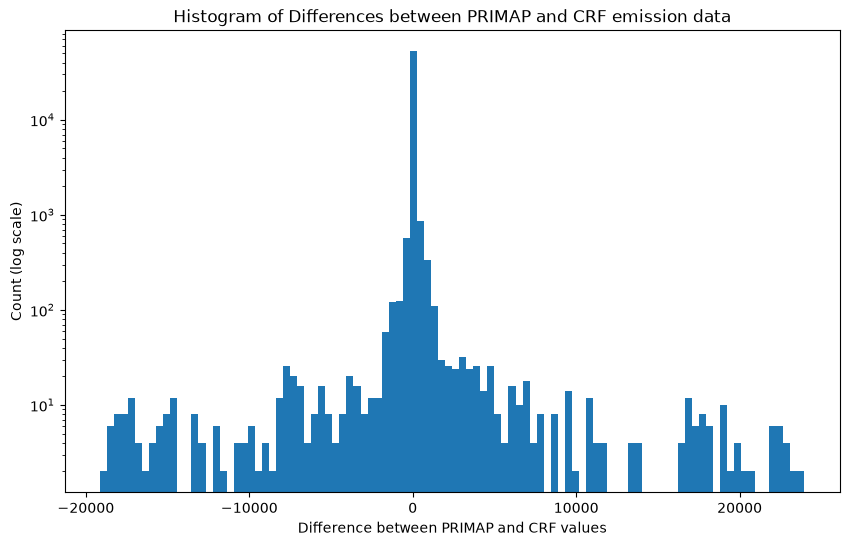

In [ ]:
# plot histogram of differences with log scale
plt.figure(figsize=(10,6))
plt.hist(merged_df["crf_diff"].dropna(), bins=100, log=True)
plt.xlabel("Difference between PRIMAP and CRF values")
plt.ylabel("Count (log scale)")
plt.title("Histogram of Differences between PRIMAP and CRF emission data")
plt.show()

We see that differences are small most of the time (notice the log scale), but there are some outliers. 

<Axes: title={'center': 'Average Absolute Difference between PRIMAP and CRF emission data per Country in kt CO2'}, xlabel='area (ISO2)'>

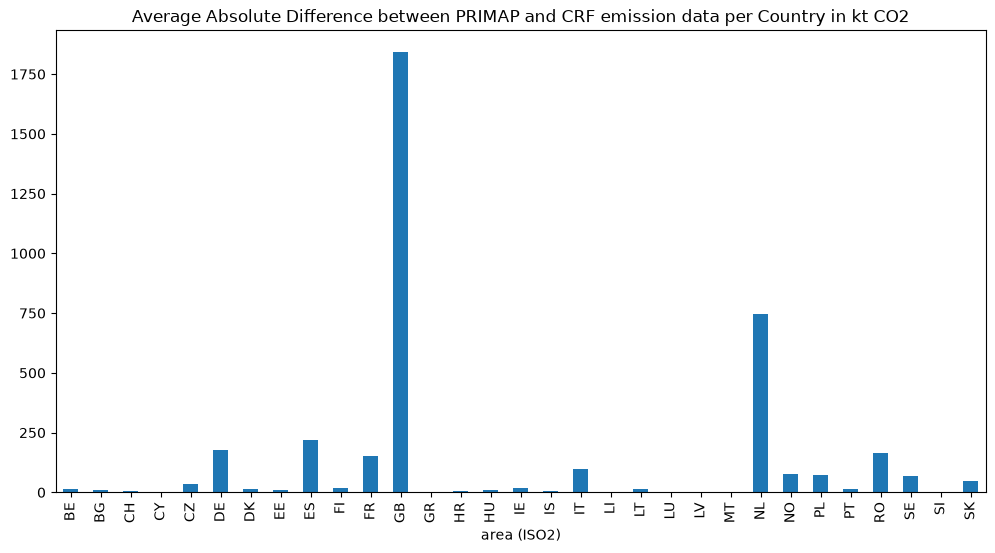

In [ ]:
# Compute the average absolute difference per country
avg_diff = merged_df.groupby(["area (ISO2)"])["abs_crf_diff"].mean()
avg_diff.plot(kind='bar', figsize=(12,6), title="Average Absolute Difference between PRIMAP and CRF emission data per Country in kt CO2")

We see that different countries align more or less with the PRIMAP-crf data.

In [ ]:
merged_df[["crf_diff", "abs_crf_diff", "rel_crf_diff"]].describe()

,crf_diff,abs_crf_diff,rel_crf_diff
count,55150.000000,55150.000000,5.515000e+04
mean,15.672387,138.691224,2.450053e+02
std,1146.876106,1138.567006,1.794083e+04
min,-19142.923709,0.000000,-9.999807e-01
25%,-0.062604,0.000678,-3.921799e-03
50%,0.000000,0.100177,0.000000e+00
75%,0.163624,5.268940,7.875090e-03
max,23961.522115,23961.522115,2.080271e+06


Now we only consider two digit levels: 

In [ ]:
merged_df[merged_df["category"].str.len() < 5]["rel_crf_diff"].describe()

count    48264.000000
mean         0.584657
std         11.308862
min         -0.997929
25%         -0.004068
50%          0.000000
75%          0.010260
max        362.903881
Name: rel_crf_diff, dtype: float64

We can see that once we restrict ourself to two digit level codes, the maximum relative difference is an outlier with 2641 kt, while the 75 percentil is already at 0.08 and the mean is 0.85. 
When we go to the main groups only, the differences diminish even further: 

In [ ]:
merged_df[merged_df["category"].str.len() <= 1]["rel_crf_diff"].describe()

count    15986.000000
mean         0.010375
std          0.355535
min         -0.996964
25%         -0.008769
50%         -0.000018
75%          0.010257
max          7.047005
Name: rel_crf_diff, dtype: float64

To sum up this exercise: There may be some larger absolute differences between our two datasets, but the relative differences are smaller. When going on more aggregate levels, the relative differences diminish strongly. This suggests, that at the aggregate levels the datasets are very similar and differences only relate to how smaller, detailled emission categories were reported, without big influences on the bigger categories and main groups.

When we look only on the totals, the relative difference is quite small. 

In [ ]:
merged_df.loc[merged_df["category"] == "M.0.EL", ["crf_diff", "abs_crf_diff", "rel_crf_diff"]].describe()

,crf_diff,abs_crf_diff,rel_crf_diff
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


## Comparison with PRIMAP-hist

Text(0.5, 1.0, 'Histogram of Differences between PRIMAP-hist and CRF emission data')

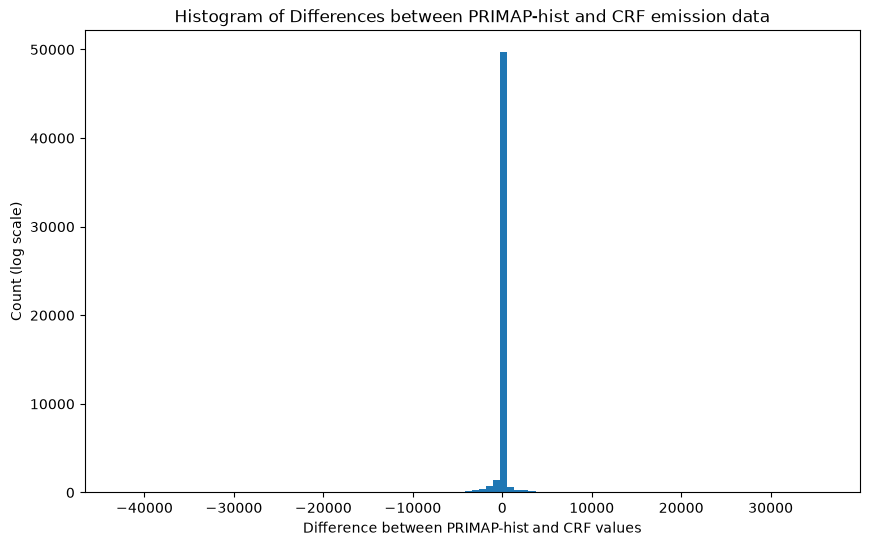

In [ ]:
# plot histogram of differences with log scale
plt.figure(figsize=(10,6))
plt.hist(merged_df["hist_diff"].dropna(), bins=100, log=False)
plt.xlabel("Difference between PRIMAP-hist and CRF values")
plt.ylabel("Count (log scale)")
plt.title("Histogram of Differences between PRIMAP-hist and CRF emission data")

We see quite some relatively large outliers, but in overall, the datasets are still relatively equal. 

In [ ]:
merged_df[["hist_diff", "abs_hist_diff", "rel_hist_diff"]].describe()

,hist_diff,abs_hist_diff,rel_hist_diff
count,55150.000000,55150.000000,5.515000e+04
mean,-97.076053,374.035620,2.139259e+02
std,1979.165250,1945.922361,1.405274e+04
min,-42749.408220,0.000000,-1.000000e+00
25%,-0.348081,0.008017,-2.351059e-02
50%,0.000000,0.461602,0.000000e+00
75%,0.757551,23.169345,5.093591e-02
max,36007.855257,42749.408220,2.198023e+06


Similarly to before, if we go to the totals level, the relative differences diminish dramastically.

In [ ]:
merged_df.loc[merged_df["category"] == "M.0.EL", ["hist_diff", "abs_hist_diff", "rel_hist_diff"]].describe()

,hist_diff,abs_hist_diff,rel_hist_diff
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN
